In [1]:
import pandas as pd

hv = pd.read_csv("../data/historical/SPY_HistoricalVolatility.csv")

hv.head()

,Date,Close,High,Low,Open,Volume,Log Return,HV20,HV60
0,2025-08-07,625.321228,629.999373,622.215625,629.267492,74205800,-0.000838,NaN,NaN
1,2025-08-08,630.197205,630.662085,626.794901,627.111401,64051600,0.007767,NaN,NaN
2,2025-08-11,628.950989,631.947812,627.704787,630.474151,58742300,-0.001979,NaN,NaN
3,2025-08-12,635.646790,635.805010,629.811423,631.294985,64730800,0.010590,NaN,NaN
4,2025-08-13,637.822754,639.108495,635.636951,637.842494,60092800,0.003417,NaN,NaN


In [2]:
calls = pd.read_csv("../data/options/SPY_Calls.csv")

In [3]:
filtered_calls = calls[
    (calls["volume"] >= 10) &
    (calls["openInterest"] >= 100)
].copy()

In [4]:
filtered_calls["IV %"] = (
    filtered_calls["impliedVolatility"] * 100
)

In [5]:
avg_iv = filtered_calls["IV %"].mean()

print(avg_iv)

16.99049869210379


In [6]:
hv["HV20%"] = (
    hv["HV20"] * 100
)
latest_hv = hv["HV20%"].iloc[-1]

print(latest_hv)

14.28955291518155


In [7]:
spread = avg_iv - latest_hv

print("Average IV:", avg_iv)
print("Latest HV:", latest_hv)
print("IV-HV Spread:", spread)

Average IV: 16.99049869210379
Latest HV: 14.28955291518155
IV-HV Spread: 2.700945776922241


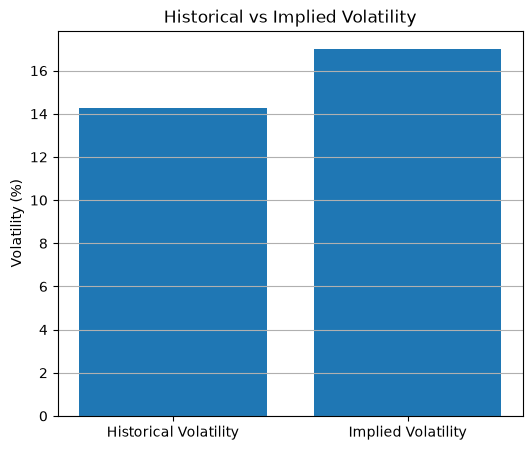

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Historical Volatility", "Implied Volatility"],
    [latest_hv, avg_iv]
)

plt.ylabel("Volatility (%)")

plt.title("Historical vs Implied Volatility")

plt.grid(axis="y")

plt.savefig(
    "../report/HV_vs_IV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

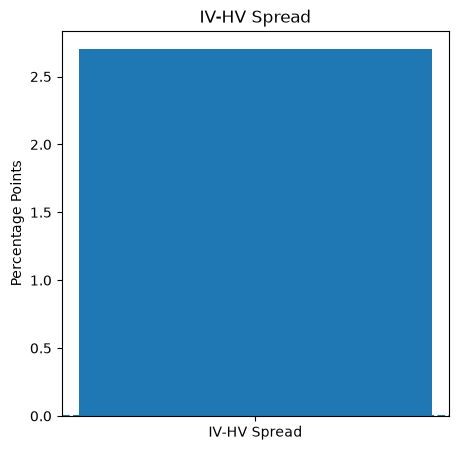

In [9]:
plt.figure(figsize=(5,5))

plt.bar(
    ["IV-HV Spread"],
    [spread]
)

plt.axhline(0, linestyle="--")

plt.ylabel("Percentage Points")

plt.title("IV-HV Spread")

plt.savefig(
    "../report/IV_HV_Spread.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()